# **Exploratory Data Analysis**

#### The goal of this analysis is to understand the structure of the MovieLens dataset before using it in my movie recommendation system. This will give a better overview of the data used.

I will be focusing on:
- Dataset size and structure
- Genre distribution
- Rating distribution
- User activity
- Movie popularity
---

### Loading the dataset

The MovieLens dataset contains several files, for this analysis the `movies.csv` and `ratings.csv` files are used.

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

movies = pd.read_csv("ml-latest/movies.csv")
ratings = pd.read_csv("ml-latest/ratings.csv")

print("Movies:", movies.shape)
print("Ratings:", ratings.shape)

Movies: (86537, 3)
Ratings: (33832162, 4)


The dataset contains a large number of movies and ratings, which means that my recommendation system needs to be able to run fast while also handling large amounts of data.

---

### Dataset Overview

In [46]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [47]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,1225734739
1,1,110,4.0,1225865086
2,1,158,4.0,1225733503
3,1,260,4.5,1225735204
4,1,356,5.0,1225735119


The *movies* dataset contains 3 columns:
- movieId
- title
- genres

The *ratings* dataset contains 4 columns:
- userId
- movieId
- rating
- timestamp

To be able to analyse movies based on ratings, the column *movieId* is used because it links the two datasets.

---

### Genre Distribution

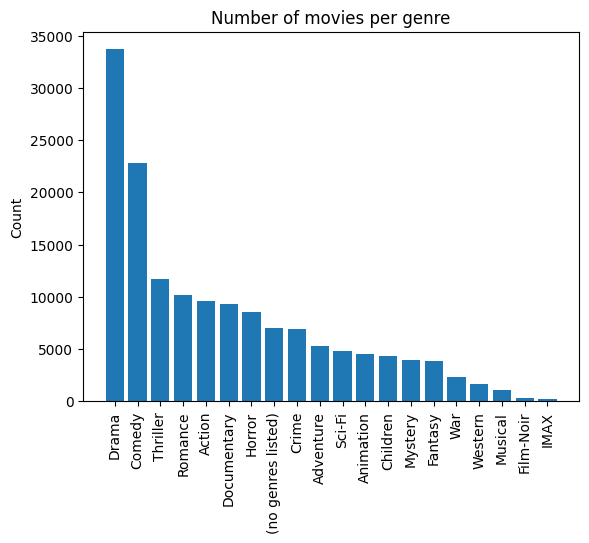

In [57]:
from recommendation_system import genres

genre_counts = genres.sum().sort_values(ascending=False)

plt.figure()
plt.bar(genre_counts.index, genre_counts.values)
plt.title("Number of movies per genre")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

The dataset contains 20 genres, with Drama, Comedy and Thriller being the most common ones. Though I noticed quickly while going through the dataset that there was one listed as *"(no genres listed)"*. 

In [49]:
genres.sum().sort_values(ascending=False)

Drama                 33681
Comedy                22830
Thriller              11675
Romance               10172
Action                 9563
Documentary            9283
Horror                 8570
(no genres listed)     7060
Crime                  6917
Adventure              5349
Sci-Fi                 4850
Animation              4579
Children               4367
Mystery                3972
Fantasy                3821
War                    2301
Western                1690
Musical                1059
Film-Noir               354
IMAX                    195
dtype: int64

While looking at the amount of movies in each genre, you can see that the *(no genres listed)* has 7060 movies linked to it. That means 7060 movies have no genres listed. It's a lot of movies but compared to the total amount of movies in the dataset, it won't affect the recommendation system. It's good to be aware of it though.

---

### Rating Distribution

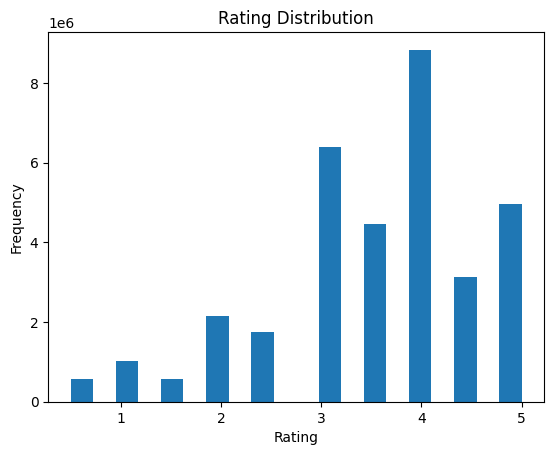

In [50]:
plt.figure()
plt.hist(ratings["rating"], bins=20)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

Here you can see the distribution of ratings in the dataset. There are over 8 million 4-star ratings for example. In average the users tend to give relatively positive ratings. 
*This may affect rating-prediction models*

---

### Number of ratings per movie

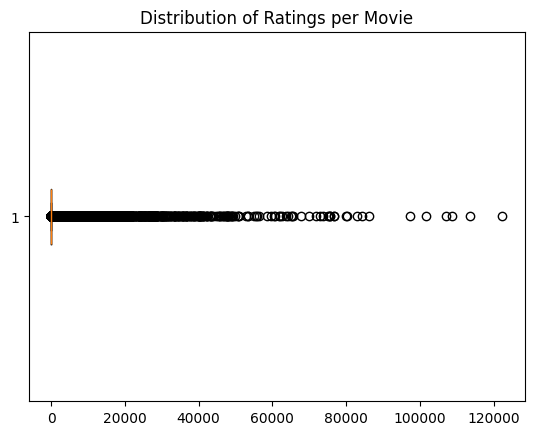

In [51]:
ratings_per_movie = ratings.groupby("movieId").size()

plt.figure()
plt.boxplot(ratings_per_movie, vert=False)
plt.title("Distribution of Ratings per Movie")
plt.show()

From the boxplot we can observe that most movies have few ratings, and only a very small number of movies are highly popular. Since less popular movies (the majority) have limited rating information, it might reduce the quality of collaborative filtering approaches. This shows clearly with the median being marked extremely low.

I tried first to visualize the dataset with a histogram, but because it has a long-tail distribution everything gets squashed on the left. With a boxplot you can easier see the difference between movies and amount of ratings

---

### User Activity

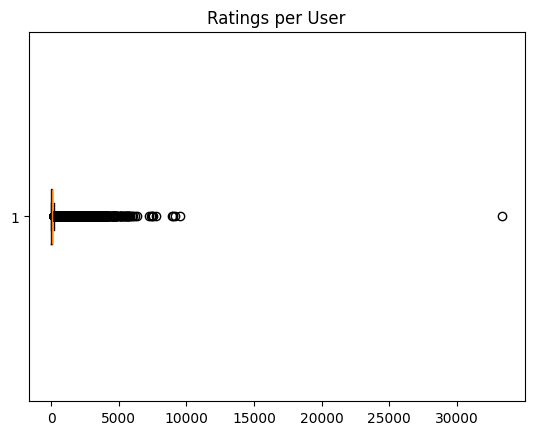

In [ ]:
ratings_per_user = ratings.groupby("userId").size()

plt.figure()
plt.boxplot(ratings_per_user, vert=False)
plt.title("Ratings per User")
plt.show()

Similiar results as with the dataset above. The user activity varies significantly, most users rate few movies while only a small amount of users rate a much higher amount of movies. This as well can make collaborative filtering more challenging. This is important to know when building recommendation systems.

---

### Most Popular Movies

In [58]:
ratings_count = ratings.groupby("movieId").size()
top_movies = ratings_count.sort_values(ascending=False).head(10)
top_movies = top_movies.reset_index(name="rating_count")
top_movies = top_movies.merge(movies, on="movieId")
top_movies[["title", "rating_count"]]

,title,rating_count
0,"Shawshank Redemption, The (1994)",122296
1,Forrest Gump (1994),113581
2,Pulp Fiction (1994),108756
3,"Matrix, The (1999)",107056
4,"Silence of the Lambs, The (1991)",101802
5,Star Wars: Episode IV - A New Hope (1977),97202
6,Fight Club (1999),86207
7,Schindler's List (1993),84232
8,Jurassic Park (1993),83026
9,Star Wars: Episode V - The Empire Strikes Back...,80200


---

### Summary

From the exploratory analysis we can conclude:
- The dataset is large and sparse
- Genre information is available for all movies
- Ratings are unevely distributed
- Many movies have few ratings

My conclusion is that a genre-based similarity model using cosine similariy and KNN is an efficient and reasonable approach for my recommendation system